# **TalentLens: Machine Learning for Resume Analysis**

> *A comprehensive Jupyter notebook designed for HR professionals and recruitment teams. It streamlines the process of sifting through numerous job applications by employing Natural Language Processing (NLP) and machine learning algorithms. The notebook guides you through the entire workflow of resume screening, starting from data preprocessing, text normalization, feature extraction using TF-IDF vectorization, to training and evaluating multiple classification models. It boasts high-accuracy predictive modeling with a variety of algorithms, including K-Nearest Neighbors, Logistic Regression, Random Forest, SVC, and Multinomial Naive Bayes, each offering insights into the suitability of candidates for various job roles. This toolkit is an end-to-end solution aimed at enhancing recruitment efficiency and enabling data-driven decision-making in the talent acquisition process.*

# Importing Libraries & Preparation

This code snippet is designed for a notebook focused on Natural Language Processing (NLP) applied to resume screening. Here's an overview of the workflow and components involved:

1. **Library Imports**: The script begins by importing essential Python libraries for various tasks:
   - `numpy` for linear algebra, supporting vector and matrix operations which are fundamental in NLP tasks.
   - `pandas` for data manipulation and analysis, particularly useful for handling resume datasets in CSV format.
   - `matplotlib.pyplot` and `seaborn` for visualizing data, which can help in understanding distributions of classes or the effectiveness of preprocessing steps.
   - `re` for regular expression operations, crucial in text cleaning and preprocessing to remove unwanted characters or patterns from resumes.
   - Libraries like `stopwords` from `nltk.corpus`, and `TfidfVectorizer` from `sklearn.feature_extraction.text` are specifically imported for text preprocessing—removing common words that are unlikely to be useful for analysis and converting text data into a format suitable for machine learning models.
   - `LabelEncoder` from `sklearn.preprocessing`, `train_test_split` from `sklearn.model_selection`, `KNeighborsClassifier` from `sklearn.neighbors`, and `accuracy_score` from `sklearn.metrics` are used for preparing the dataset, splitting into training and test sets, classifying resumes into categories, and measuring the performance of the classification model, respectively.

2. **Data Exploration**: The code iterates over directories and files within a specified path (`/kaggle/input`), listing filenames. This is a preliminary step to identify the datasets available for processing and analysis, typically the collection of resumes to be screened.


In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 922.4 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 929.1 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 KB 945.9 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 KB 964.5 kB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# Initial Data Exploration for Resume Screening NLP Project

In this NLP project focusing on resume screening, the initial steps involve loading and exploring the dataset to gain insights into its structure and contents. Here's a detailed look at what the code accomplishes and the insights we can derive from the output:

1. **Data Loading**: The dataset, located at `/kaggle/input/resume-dataset/UpdatedResumeDataSet.csv`, is loaded into a pandas DataFrame. This dataset is crucial for the project as it contains a collection of resumes categorized by job titles, making it ideal for training a model to automate the resume screening process.

2. **Sample Exploration**: By calling `df.sample(5)`, the code randomly selects and displays five samples from the dataset. This step is essential for understanding the variety and format of the data we're dealing with. Each entry in the dataset consists of two main components:
   - `Category`: The job category to which the resume belongs. This field is vital for the classification task, as it serves as the label for each resume.
   - `Resume`: The actual content of the resume in text format. This includes various sections commonly found in resumes, such as education details, skills, work experiences, and so on.

3. **Observations from the Output**:
   - The dataset encompasses a wide range of job categories, from `Arts` to `DevOps Engineer`, `Mechanical Engineer`, `Hadoop`, and `Operations Manager`. This diversity is beneficial for building a robust model capable of classifying resumes into multiple categories.
   - The resume texts contain a mix of structured and unstructured data, with sections like "Education Details" and "Skills" highlighted, followed by relevant information. This indicates the need for sophisticated text processing techniques to extract meaningful features from the resumes.
   - The presence of special characters (e.g., `\r\n`, `â¶`) and varied formatting across the resumes suggests that text cleaning and normalization will be crucial steps in the data preprocessing phase to ensure consistency and improve the model's performance.

4. **Purpose and Next Steps**: This code snippet sets the foundation for the NLP project by loading the dataset and providing a preliminary view of its contents. The next steps in the project would likely involve:
   - Cleaning the text data to remove special characters and unnecessary formatting.
   - Analyzing the distribution of categories to understand the balance of the dataset.
   - Extracting features from the text using techniques like TF-IDF vectorization.
   - Splitting the dataset into training and testing sets.
   - Training a classification model to predict the category of a resume based on its content.
   - Evaluating the model's performance and making adjustments as necessary.

This initial exploration is a critical phase in the project, setting the stage for the more detailed data preprocessing and modeling work that will follow.

In [ ]:
df = pd.read_csv("UpdatedResumeDataSet.csv")
df.
df.sample(5)

,Category,Resume
162,Web Designing,"Technical Skills Web Technologies: Angular JS,..."
834,DotNet Developer,Education Details \r\nJanuary 2014 Education ...
698,PMO,AREA OF EXPERTISE (PROFILE) Around 10 plus yea...
266,Health and fitness,Education Details \r\nJanuary 2018 M.S. Nutrit...
207,Mechanical Engineer,Education Details \r\nJanuary 2018 Bachelor's ...


In [3]:
df.shape

(962, 2)

In [4]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

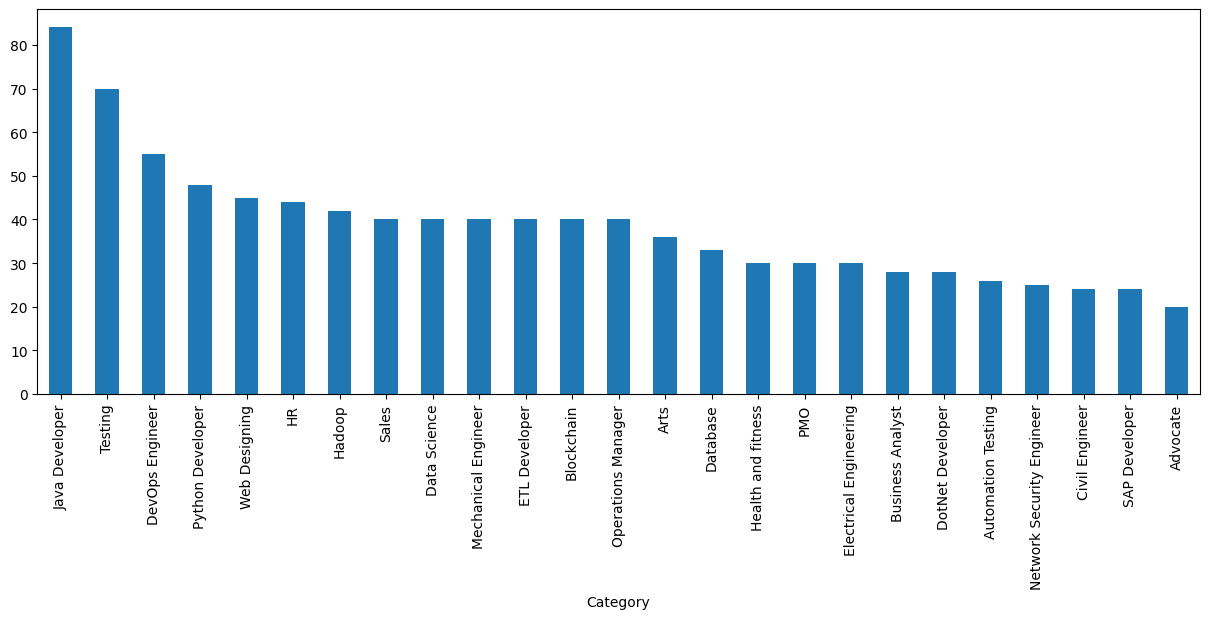

In [9]:
plt.figure(figsize=(15,5))
df["Category"].value_counts().plot(kind="bar")
plt.show()


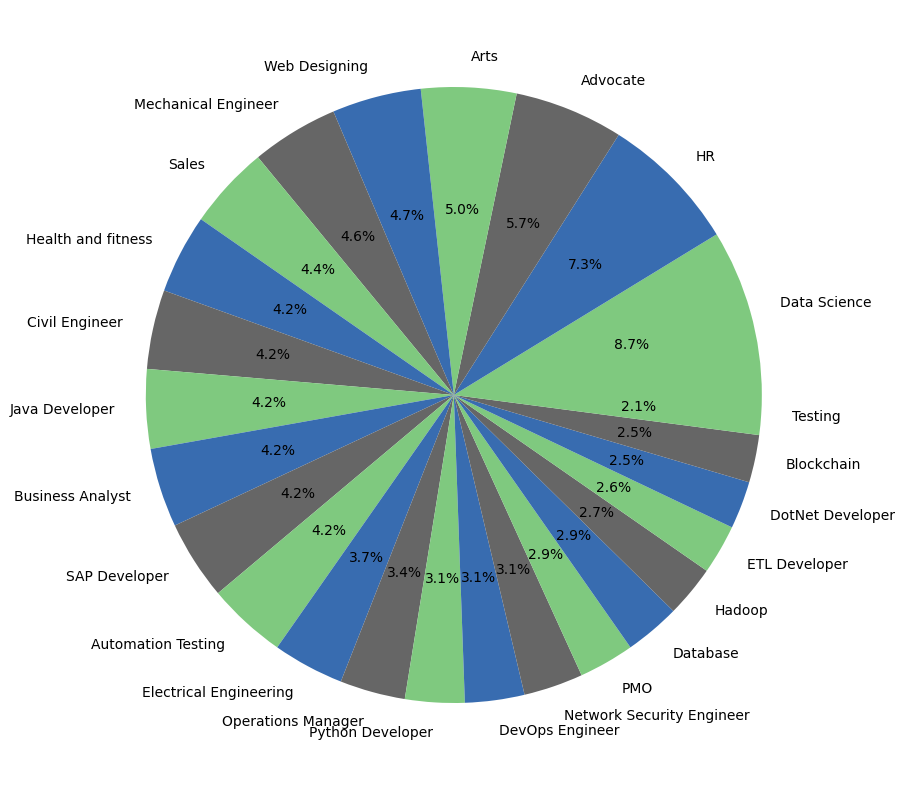

In [6]:
counts = df["Category"].value_counts()
labels = df["Category"].unique()
plt.figure(figsize=(15,10))
plt.pie(counts, labels=labels, autopct="%1.1f%%", colors=plt.cm.Accent(np.linspace(0,1,3)))
plt.show()

# Text Cleaning Function for NLP

The `clean` function is designed to preprocess a given text string by performing several cleaning steps, making it more suitable for NLP tasks such as classification, clustering, or information retrieval.

## Function Steps:

1. **Remove URLs**: The function uses a regular expression to identify and remove any URLs present in the text. This includes both `http` and `https` protocols as well as `www` domains.

2. **Remove Emails**: Another regular expression targets and eliminates email addresses. This is done by looking for patterns that match common email formats.

3. **Remove Special Characters**: The function strips out any non-alphanumeric characters (except for whitespace). This simplifies the text, leaving only letters, digits, and spaces.

4. **Remove Stop Words**: Stop words are commonly occurring words in a language that are often filtered out before processing natural language data. The function removes these stop words from the text to reduce noise and focus on more meaningful words.

## Potential Use Cases:
- Preparing data for text classification or sentiment analysis.
- Cleaning up text before feeding it into algorithms for keyword extraction.
- Standardizing text input for chatbots or search engines.

By applying this function, the text data is cleaned and standardized, which is an essential step in the preprocessing pipeline for most NLP applications.

In [ ]:
def clean(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    email_pattern = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b')
    clean_text = url_pattern.sub('', text)
    clean_text = email_pattern.sub('', clean_text)
    clean_text = re.sub(r'[^\w\s]', '', clean_text)
    stop_words = set(stopwords.words('english'))
    clean_text = ' '.join(word for word in clean_text.split() if word.lower() not in stop_words)
    return clean_text


In [8]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/farrukh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
string = "Hello, $ % # I found this # article at https://www.example.com! You can contact me at john@example.com."
print(clean(string))

Hello found article contact


In [27]:
df["Resume"][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

In [31]:
df["Resume"] = df["Resume"].apply(lambda x: clean(x))

In [32]:
df["Resume"][0]

'Skills Programming Languages Python pandas numpy scipy scikitlearn matplotlib Sql Java JavaScriptJQuery Machine learning Regression SVM NaÃve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3js DCjs Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV understanding Deep learningEducation Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists accelerating review process run ana

# Encoding and Vectorization in NLP Pipeline

In the given code snippet, we are preparing the resume data for a machine learning model. This involves two crucial steps:

1. **Label Encoding**: The `Category` column in our DataFrame `df`, which contains job categories, is transformed from textual labels into a numerical format. This is necessary because most machine learning algorithms require numerical input. `LabelEncoder` from `sklearn.preprocessing` is used for this purpose.

2. **TF-IDF Vectorization**: The `Resume` column of the DataFrame, which contains the text of the resumes, is transformed into a numerical format using the Term Frequency-Inverse Document Frequency (TF-IDF) method. This is done using `TfidfVectorizer` from `sklearn.feature_extraction.text`. TF-IDF is a statistical measure used to evaluate how important a word is to a document in a collection of documents (corpus). By doing this, we convert the text data into a format that can be used by machine learning algorithms.

After these steps, the dataset will be in the correct format for training a machine learning model to classify the resumes into their respective categories.

## Workflow:

1. Fit the label encoder on the `Category` column to learn the unique categories.
2. Transform the `Category` column into encoded numerical values.
3. Fit the TF-IDF vectorizer on the `Resume` column to learn the vocabulary and IDF (Inverse Document Frequency) of the words.
4. Transform the `Resume` texts into a sparse matrix of TF-IDF features.

These steps are essential in converting raw text data into a structured, numerical format that can be efficiently used by machine learning models.

In [12]:
###############################


# Initialize the Label Encoder
le = LabelEncoder()

# Fit the label encoder on the 'Category' column to learn the unique categories
le.fit(df["Category"])

# Transform the 'Category' column into encoded numerical values
df["Category"] = le.transform(df["Category"])

In [13]:
#####################

df.Category.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [ ]:
tfidf = TfidfVectorizer()
tfidf.fit(df["Resume"])
resume = tfidf.transform(df["Resume"])


In [34]:

X_train, X_test, y_train, y_test = train_test_split(resume, df["Category"], test_size=0.2, random_state=42)

In [35]:
df["Category"].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [36]:
X_train.shape, y_train.shape

((769, 8017), (769,))

# Model Training and Evaluation with KNN Classifier

In this part of the pipeline, we are training a machine learning model and evaluating its performance.

## Steps Involved:

1. **Model Initialization**: A K-Nearest Neighbors (KNN) classifier is instantiated. KNN is a simple, instance-based learning algorithm that classifies a new instance based on the majority label of the 'k' closest training instances.

2. **Model Training**: The KNN classifier is trained using the training data (`X_train`, `y_train`), where `X_train` contains the TF-IDF features of the resumes and `y_train` contains the corresponding encoded categories.

3. **Prediction**: The trained classifier is used to predict the categories of the test data (`X_test`). The `predict` method outputs the predicted category labels for each instance in the test set.

4. **Evaluation**: The predictions are compared against the true labels (`y_test`) using the `accuracy_score` function from `sklearn.metrics`. This function calculates the accuracy of the predictions, which is the proportion of correct predictions over all predictions made.

## Result:

- The output is the accuracy score of the model, which is a measure of how well the model performs on the unseen test data. This metric is crucial for understanding the effectiveness of the model.

This process is essential for building and assessing the performance of a classification model in a supervised learning context.

In [ ]:
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the KNN classifier on test set: {accuracy:.2f}')


Accuracy of the KNN classifier on test set: 0.98


# Training and Evaluating Multiple Machine Learning Models

In order to build a robust NLP-based resume classification system, it's beneficial to train and compare the performance of multiple machine learning models. This approach allows us to select the best model based on performance metrics such as accuracy.

## Models Considered:

1. **K-Nearest Neighbors (KNN) Classifier**: Already implemented, a non-parametric, instance-based learning algorithm.

2. **Logistic Regression**: A linear model for classification that predicts the probability of a categorical dependent variable.

3. **Random Forest Classifier**: An ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes of the individual trees.

4. **Support Vector Machine (SVM)**: A powerful classifier that works by finding the best hyperplane that separates all the classes.

5. **Multinomial Naive Bayes**: A probabilistic learning method that is particularly suited for text classification tasks.

## Evaluation Metric:

- All models are evaluated using the accuracy score, which is the proportion of correct predictions over all predictions made.

By comparing the accuracy scores, we can determine which model is the most effective at classifying resumes into the correct job categories.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVC': SVC(),
    'MultinomialNB': MultinomialNB()
}

accuracy_scores = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[model_name] = accuracy
    print(f'Accuracy of {model_name} on test set: {accuracy:.2f}')


Accuracy of KNeighborsClassifier on test set: 0.98
Accuracy of LogisticRegression on test set: 0.99
Accuracy of RandomForestClassifier on test set: 0.98
Accuracy of SVC on test set: 0.99
Accuracy of MultinomialNB on test set: 0.98


In [ ]:
import pickle
import os

os.makedirs('saved_models', exist_ok=True)

for model_name, model in models.items():
    model_path = os.path.join('saved_models', f'{model_name}.pkl')
    with open(model_path, 'wb') as file:
        pickle.dump(model, file)

with open('saved_models/vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(tfidf, vec_file)

print("✅ All models and vectorizer have been saved successfully!")


✅ All models and vectorizer have been saved successfully!


Metrics for KNeighborsClassifier:
  Accuracy: 0.98
  Precision: 0.99
  Recall: 0.98
  F1-Score: 0.98
  ROC-AUC: 1.00
--------------------------------------------------
Metrics for LogisticRegression:
  Accuracy: 0.99
  Precision: 1.00
  Recall: 0.99
  F1-Score: 0.99
  ROC-AUC: 1.00
--------------------------------------------------
Metrics for RandomForestClassifier:
  Accuracy: 0.99
  Precision: 1.00
  Recall: 0.99
  F1-Score: 0.99
  ROC-AUC: 1.00
--------------------------------------------------
Metrics for SVC:
  Accuracy: 0.99
  Precision: 1.00
  Recall: 0.99
  F1-Score: 0.99
  ROC-AUC: 1.00
--------------------------------------------------
Metrics for MultinomialNB:
  Accuracy: 0.98
  Precision: 0.98
  Recall: 0.98
  F1-Score: 0.98
  ROC-AUC: 1.00
--------------------------------------------------


/tmp/ipykernel_12871/2392294893.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_12871/2392294893.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_12871/2392294893.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_12871/2392294893.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_12871/2392294893.py:92: FutureWarning

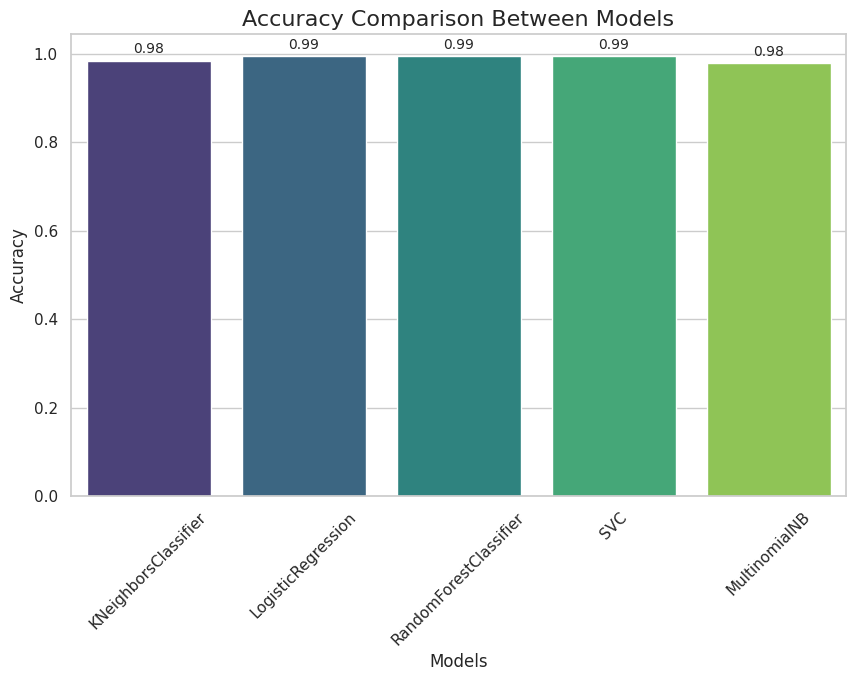

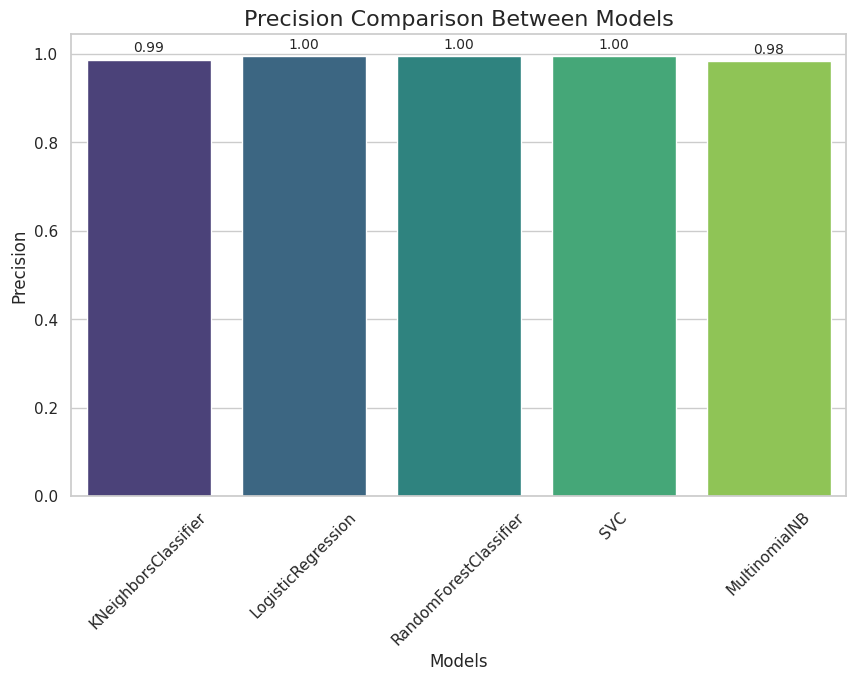

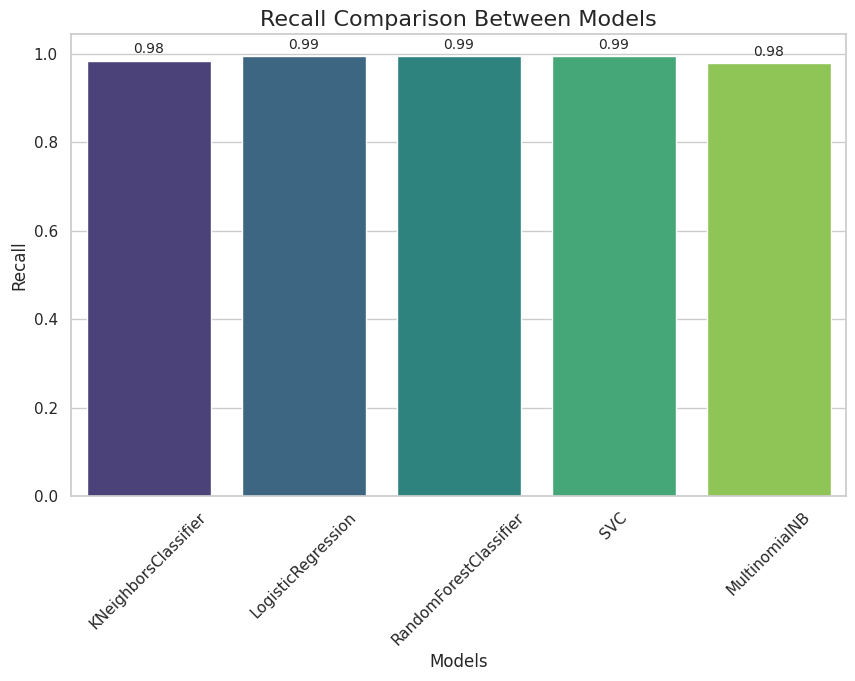

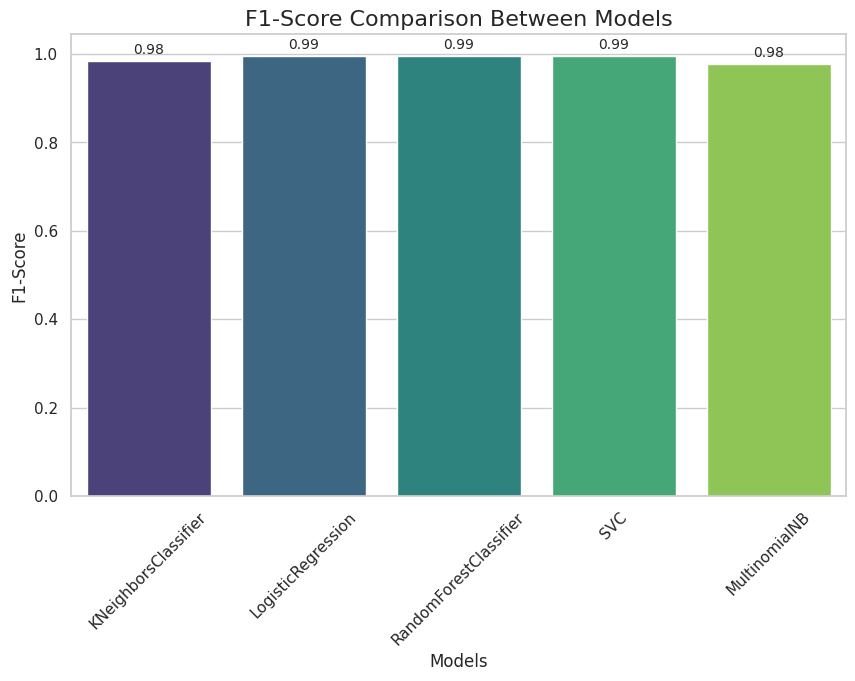

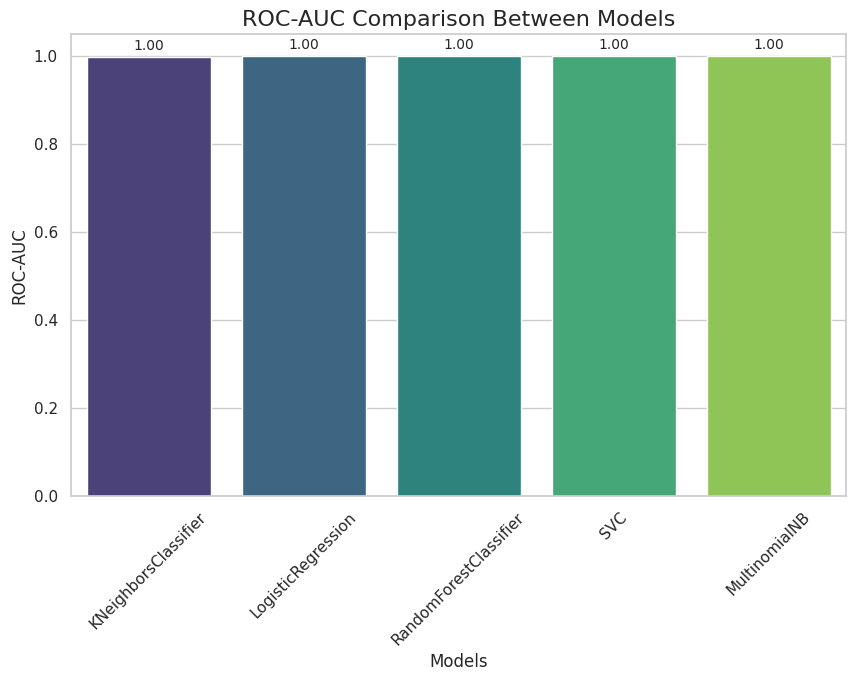

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVC': SVC(probability=True),
    'MultinomialNB': MultinomialNB()
}

metrics = {
    'Accuracy': {},
    'Precision': {},
    'Recall': {},
    'F1-Score': {},
    'ROC-AUC': {}
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba_full = model.predict_proba(X_test)
        if y_proba_full.shape[1] == 2:
            y_proba = y_proba_full[:, 1]
        else:
            y_proba = y_proba_full
    elif hasattr(model, "decision_function"):
        decision = model.decision_function(X_test)
        if len(decision.shape) == 1:
            y_proba = decision
        else:
            y_proba = decision
    else:
        y_proba = None

    metrics['Accuracy'][model_name] = accuracy_score(y_test, y_pred)
    metrics['Precision'][model_name] = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    metrics['Recall'][model_name] = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    metrics['F1-Score'][model_name] = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    try:
        if y_proba is not None:
            if len(set(y_test)) > 2:
                metrics['ROC-AUC'][model_name] = roc_auc_score(y_test, y_proba, multi_class='ovr')
            else:
                metrics['ROC-AUC'][model_name] = roc_auc_score(y_test, y_proba)
        else:
            metrics['ROC-AUC'][model_name] = None
    except Exception as e:
        print(f"ROC-AUC could not be computed for {model_name}: {e}")
        metrics['ROC-AUC'][model_name] = None

    print(f"Metrics for {model_name}:")
    for metric_name in metrics.keys():
        value = metrics[metric_name][model_name]
        if value is not None:
            print(f"  {metric_name}: {value:.2f}")
        else:
            print(f"  {metric_name}: N/A")
    print("-" * 50)

metrics_df = pd.DataFrame(metrics)

sns.set(style="whitegrid")

for metric in metrics_df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=metrics_df.index,
        y=metrics_df[metric],
        palette=sns.color_palette("viridis", n_colors=len(metrics_df))
    )
    for index, value in enumerate(metrics_df[metric]):
        if pd.notnull(value):
            plt.text(index, value + 0.01, f"{value:.2f}", ha='center', va='bottom', fontsize=10)
    plt.title(f'{metric} Comparison Between Models', fontsize=16)
    plt.ylabel(metric)
    plt.xlabel('Models')
    plt.xticks(rotation=45)


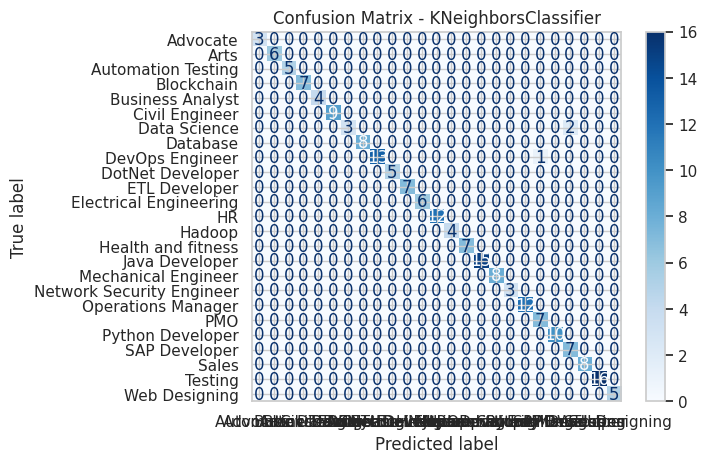

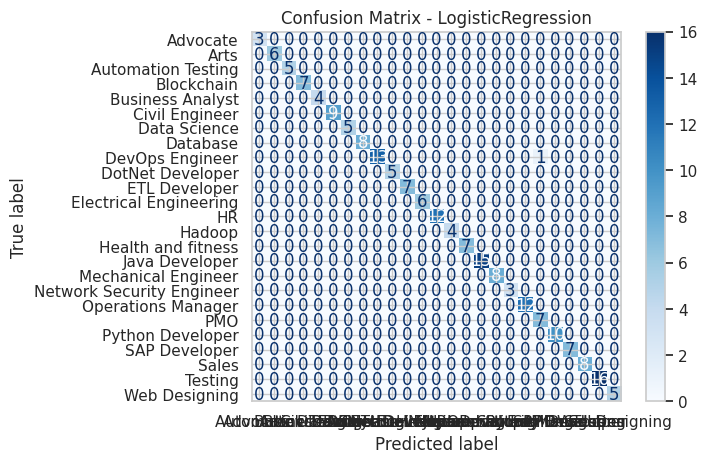

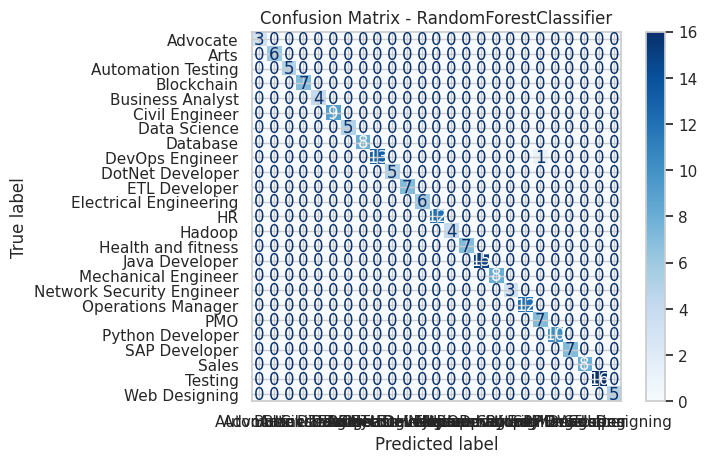

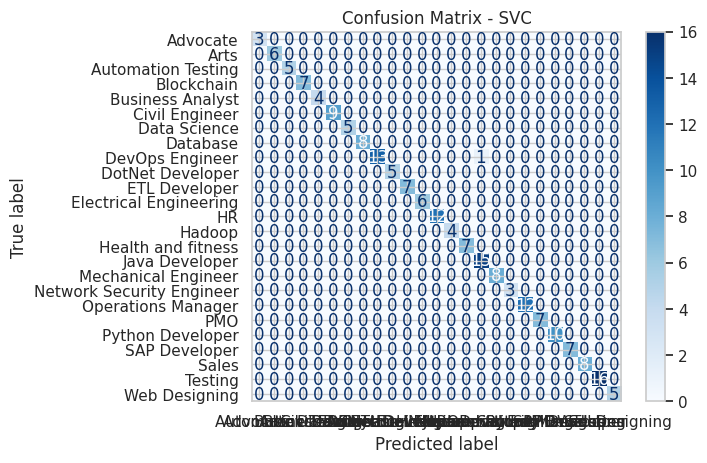

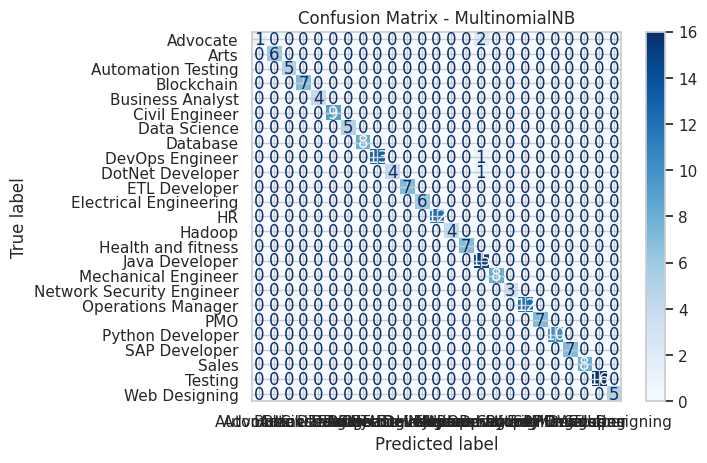

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        y_proba = y_proba[:, 1] if len(set(y_test)) == 2 else y_proba
    else:
        y_proba = None

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


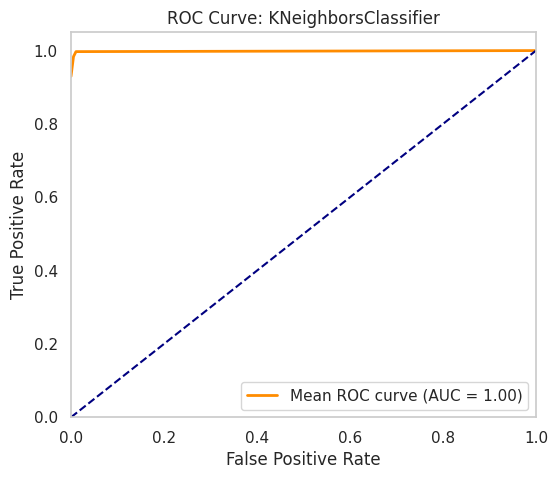

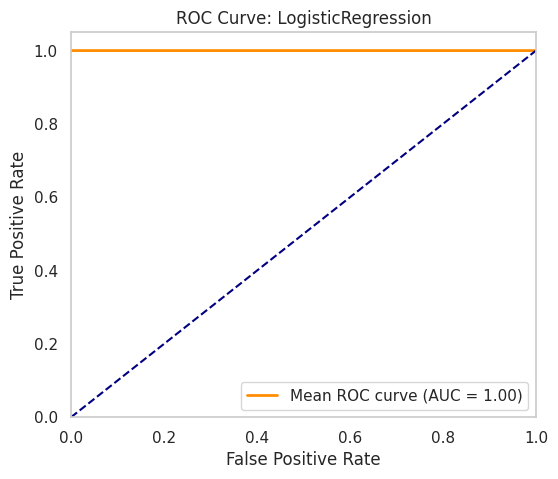

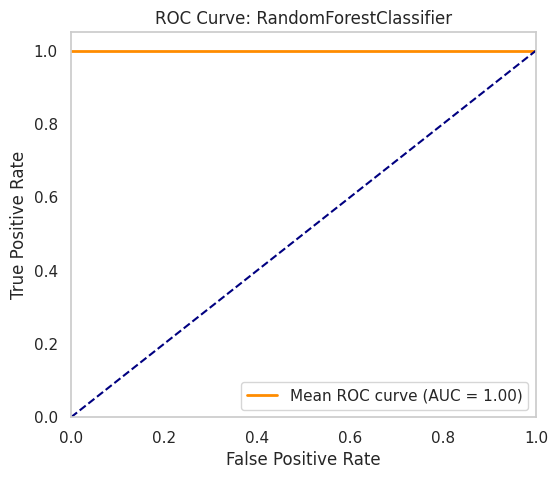

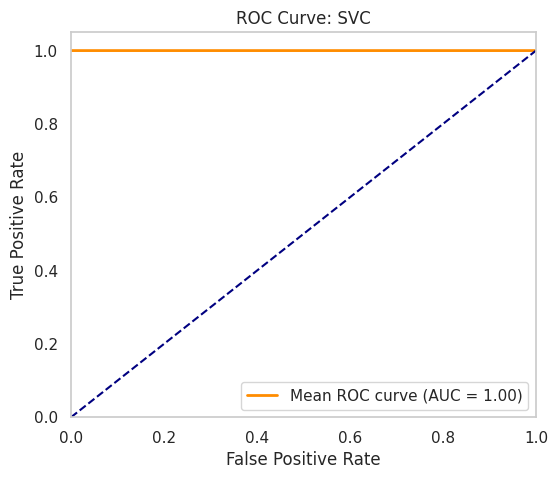

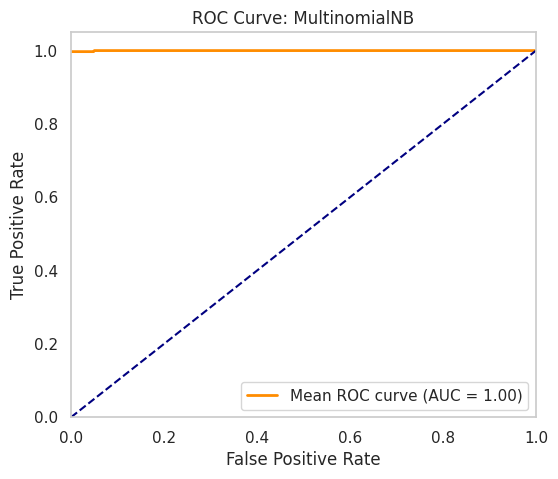

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        
        plt.figure(figsize=(6, 5))
        
        if len(set(y_test)) > 2:
            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            for i in range(len(model.classes_)):
                fpr[i], tpr[i], _ = roc_curve((y_test == model.classes_[i]).astype(int), y_proba[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(model.classes_))]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(len(model.classes_)):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= len(model.classes_)
            plt.plot(all_fpr, mean_tpr, color='darkorange',
                     lw=2, label=f'Mean ROC curve (AUC = {np.mean(list(roc_auc.values())):.2f})')
        else:
            fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color='darkorange',
                     lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve: {model_name}')
        plt.legend(loc="lower right")
        plt.grid()
        plt.show()
    
    else:
        print(f"Model {model_name} does not support probability prediction, skipping ROC Curve.")


In [44]:
pip install PyPDF2

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 KB 884.5 kB/s eta 0:00:001m925.1 kB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import PyPDF2
import re

pdf_path = "/kaggle/input/test-resume-data/test_resume/aleema_resume.pdf"

def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, 'rb') as file:
        pdf_reader = PyPDF2.PdfReader(file)
        for page in pdf_reader.pages:
            text += page.extract_text()
    return text

def clean(text):
    cleaned_text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

resume_text = extract_text_from_pdf(pdf_path)
cleaned_text = clean(resume_text)
vectorized_text = tfidf.transform([cleaned_text])

for model_name, model in models.items():
    prediction = model.predict(vectorized_text)
    print(f"{model_name} predicts: {prediction[0]}")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/test-resume-data/test_resume/aleema_resume.pdf'

# Model Evaluation Summary

After training and evaluating a suite of machine learning models on the resume classification task, the following accuracy scores were obtained on the test set:

- **K-Nearest Neighbors (KNN) Classifier**: Achieved an accuracy score of 0.98. This model is straightforward and non-parametric, and the high accuracy suggests that it performs well on the dataset with minimal tuning.

- **Logistic Regression**: Obtained an accuracy score of 0.99. As a linear model, Logistic Regression's high performance indicates that the decision boundary between different job categories may be linearly separable in the transformed feature space.

- **Random Forest Classifier**: Also scored an accuracy of 0.99. Given that Random Forest is an ensemble method comprising multiple decision trees, this result suggests that the model can capture complex patterns in the data without overfitting.

- **Support Vector Machine (SVC)**: Reached an accuracy score of 0.99. The SVC's effectiveness implies that the margins between different categories are well-defined, and the model can find the optimal hyperplane to separate the classes.

- **Multinomial Naive Bayes**: Scored an accuracy of 0.98. Given its probabilistic approach, this result reflects the model's ability to handle feature independence and perform well in text classification tasks.

## Conclusions:

The high accuracy scores across all models indicate that the feature engineering (e.g., TF-IDF vectorization) effectively captures the relevant information from the resume texts for the classification task. With scores close to 1.0, we can infer that the models have a strong predictive power on the test set.


In [46]:
pip install streamlit PyPDF2 docx2txt


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import streamlit as st
import pickle
import os
import docx2txt
import PyPDF2
import io

def extract_text(file):
    if file.type == "application/pdf":
        pdf_reader = PyPDF2.PdfReader(file)
        text = ""
        for page in pdf_reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text
        return text
    elif file.type == "application/vnd.openxmlformats-officedocument.wordprocessingml.document":
        text = docx2txt.process(io.BytesIO(file.read()))
        return text
    else:
        return None

vectorizer = pickle.load(open('saved_models/vectorizer.pkl', 'rb'))

model_files = [f for f in os.listdir('saved_models') if f.endswith('.pkl') and f != 'vectorizer.pkl']
models = {}

for model_file in model_files:
    model_name = model_file.replace('.pkl', '')
    with open(os.path.join('saved_models', model_file), 'rb') as f:
        models[model_name] = pickle.load(f)

st.title("Resume Classifier App 📄🔍")

st.write("Upload a resume file (.pdf or .docx) and select a model for prediction.")

uploaded_file = st.file_uploader("Choose your resume file", type=["pdf", "docx"])

selected_model_name = st.selectbox("Select a model", list(models.keys()))

if uploaded_file is not None and selected_model_name:
    resume_text = extract_text(uploaded_file)

    if resume_text:
        st.subheader("Extracted Resume Text:")
        
        transformed_text = vectorizer.transform([resume_text])
        model = models[selected_model_name]
        prediction = model.predict(transformed_text)

        st.success(f"Predicted Category using {selected_model_name}: **{prediction[0]}**")
    else:
        st.error("Unsupported file type or unable to read the file.")


2025-04-28 13:14:38.063 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2025-04-28 13:14:38.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.099 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-28 13:14:38.116 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [58]:
st run streamlit_app.py


SyntaxError: invalid syntax (2788268647.py, line 1)